In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [2]:
dfi=pd.read_csv('RECLAMEAQUI_IBYTE.csv')

In [3]:
dfi.head()

,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS
0,21898349,Quebraram a tela do meu Notebook,Hidrolândia - CE,2016-02-11,Ibyte - Loja Física<->Informática,Resolvido,Em 05/10/2016 deixei meu Notebook para consert...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,2,11,42,6,3,1,1
1,22581481,Solicitação de Cancelamento de Compra,Araxá - MG,2016-03-12,Não consigo fazer operação por telefone<->Cana...,Em réplica,"Prezados, efetuei uma compra no site www.ameri...",https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,3,12,72,10,5,1,2
2,22579385,Inutilizarão a tela do meu notebook,Fortaleza - CE,2016-03-12,Problemas na Loja<->Ibyte - Loja Física<->Prod...,Respondida,Decidi conserta meu notebook que parou de inic...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,3,12,72,10,5,1,2
3,21328791,Produto não faz o que vendedor informa!,Fortaleza - CE,2016-04-10,Ibyte - Loja Física<->Impressoras<->Produto er...,Em réplica,Venho através desde canal de reclamação expor ...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,4,10,101,14,6,2,1
4,22608043,Ibyte não troca o produto,Fortaleza - CE,2016-05-12,Smartphone<->Celulares e Smartphones<->Blackfr...,Respondida,Comprei um celular na black Friday e com 4 dia...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,5,12,133,19,3,2,2


In [4]:
categorias=[]
lixo='Ibyte - Loja Física'
for i in range(len(dfi)):
    categorias=categorias+dfi.CATEGORIA.iloc[i].split('<->')


In [5]:
categorias

['Ibyte - Loja Física',
 'Informática',
 'Não consigo fazer operação por telefone',
 'Canais de Atendimento',
 'Ibyte - Loja Física',
 'Problemas com o Atendimento',
 'Problemas na Loja',
 'Ibyte - Loja Física',
 'Produto danificado',
 'Entrega',
 'Ibyte - Loja Física',
 'Impressoras',
 'Produto errado',
 'Informática',
 'Smartphone',
 'Celulares e Smartphones',
 'Blackfriday',
 'Problemas de sinal',
 'Ibyte - Loja Física',
 'Acessórios para Celulares, Tablets e Computadores',
 'Ibyte - Loja Física',
 'Outros',
 'Ibyte - Loja Física',
 'Eletroeletrônicos',
 'Lentidão-travamento',
 'Acessórios para Celulares, Tablets e Computadores',
 'HDs externos e pen drives',
 'Ibyte - Loja Física',
 'Propaganda enganosa',
 'Ibyte - Loja Física',
 'Atraso na entrega',
 'Informática',
 'Multifuncionais',
 'Comportamento do profissional',
 'Ibyte - Loja Física',
 'Equipe de Atendimento',
 'Problemas com o Atendimento',
 'Tela trincada',
 'Ibyte - Loja Física',
 'TV',
 'Eletroeletrônicos',
 'Acessórios

In [6]:
dc=pd.DataFrame({'CATEGORIA':categorias})

In [7]:
dc.CATEGORIA.value_counts()

CATEGORIA
Ibyte - Loja Física                                  1000
Informática                                           337
Acessórios para Celulares, Tablets e Computadores     153
Outro Tipo de produto/Serviço                         115
Eletroeletrônicos                                     108
                                                     ... 
Fila                                                    1
Bolsas e Malas                                          1
Qualidade da impressão                                  1
Demora para carregar                                    1
Máquina fotográfica                                     1
Name: count, Length: 131, dtype: int64

In [8]:
dc=dc[dc.CATEGORIA!=lixo]

In [9]:
dc.CATEGORIA.value_counts()

CATEGORIA
Informática                                          337
Acessórios para Celulares, Tablets e Computadores    153
Outro Tipo de produto/Serviço                        115
Eletroeletrônicos                                    108
Produto com defeito                                  107
                                                    ... 
Fila                                                   1
Qualidade da impressão                                 1
Demora para carregar                                   1
Problemas com as ligações                              1
Máquina fotográfica                                    1
Name: count, Length: 130, dtype: int64

<BarContainer object of 30 artists>

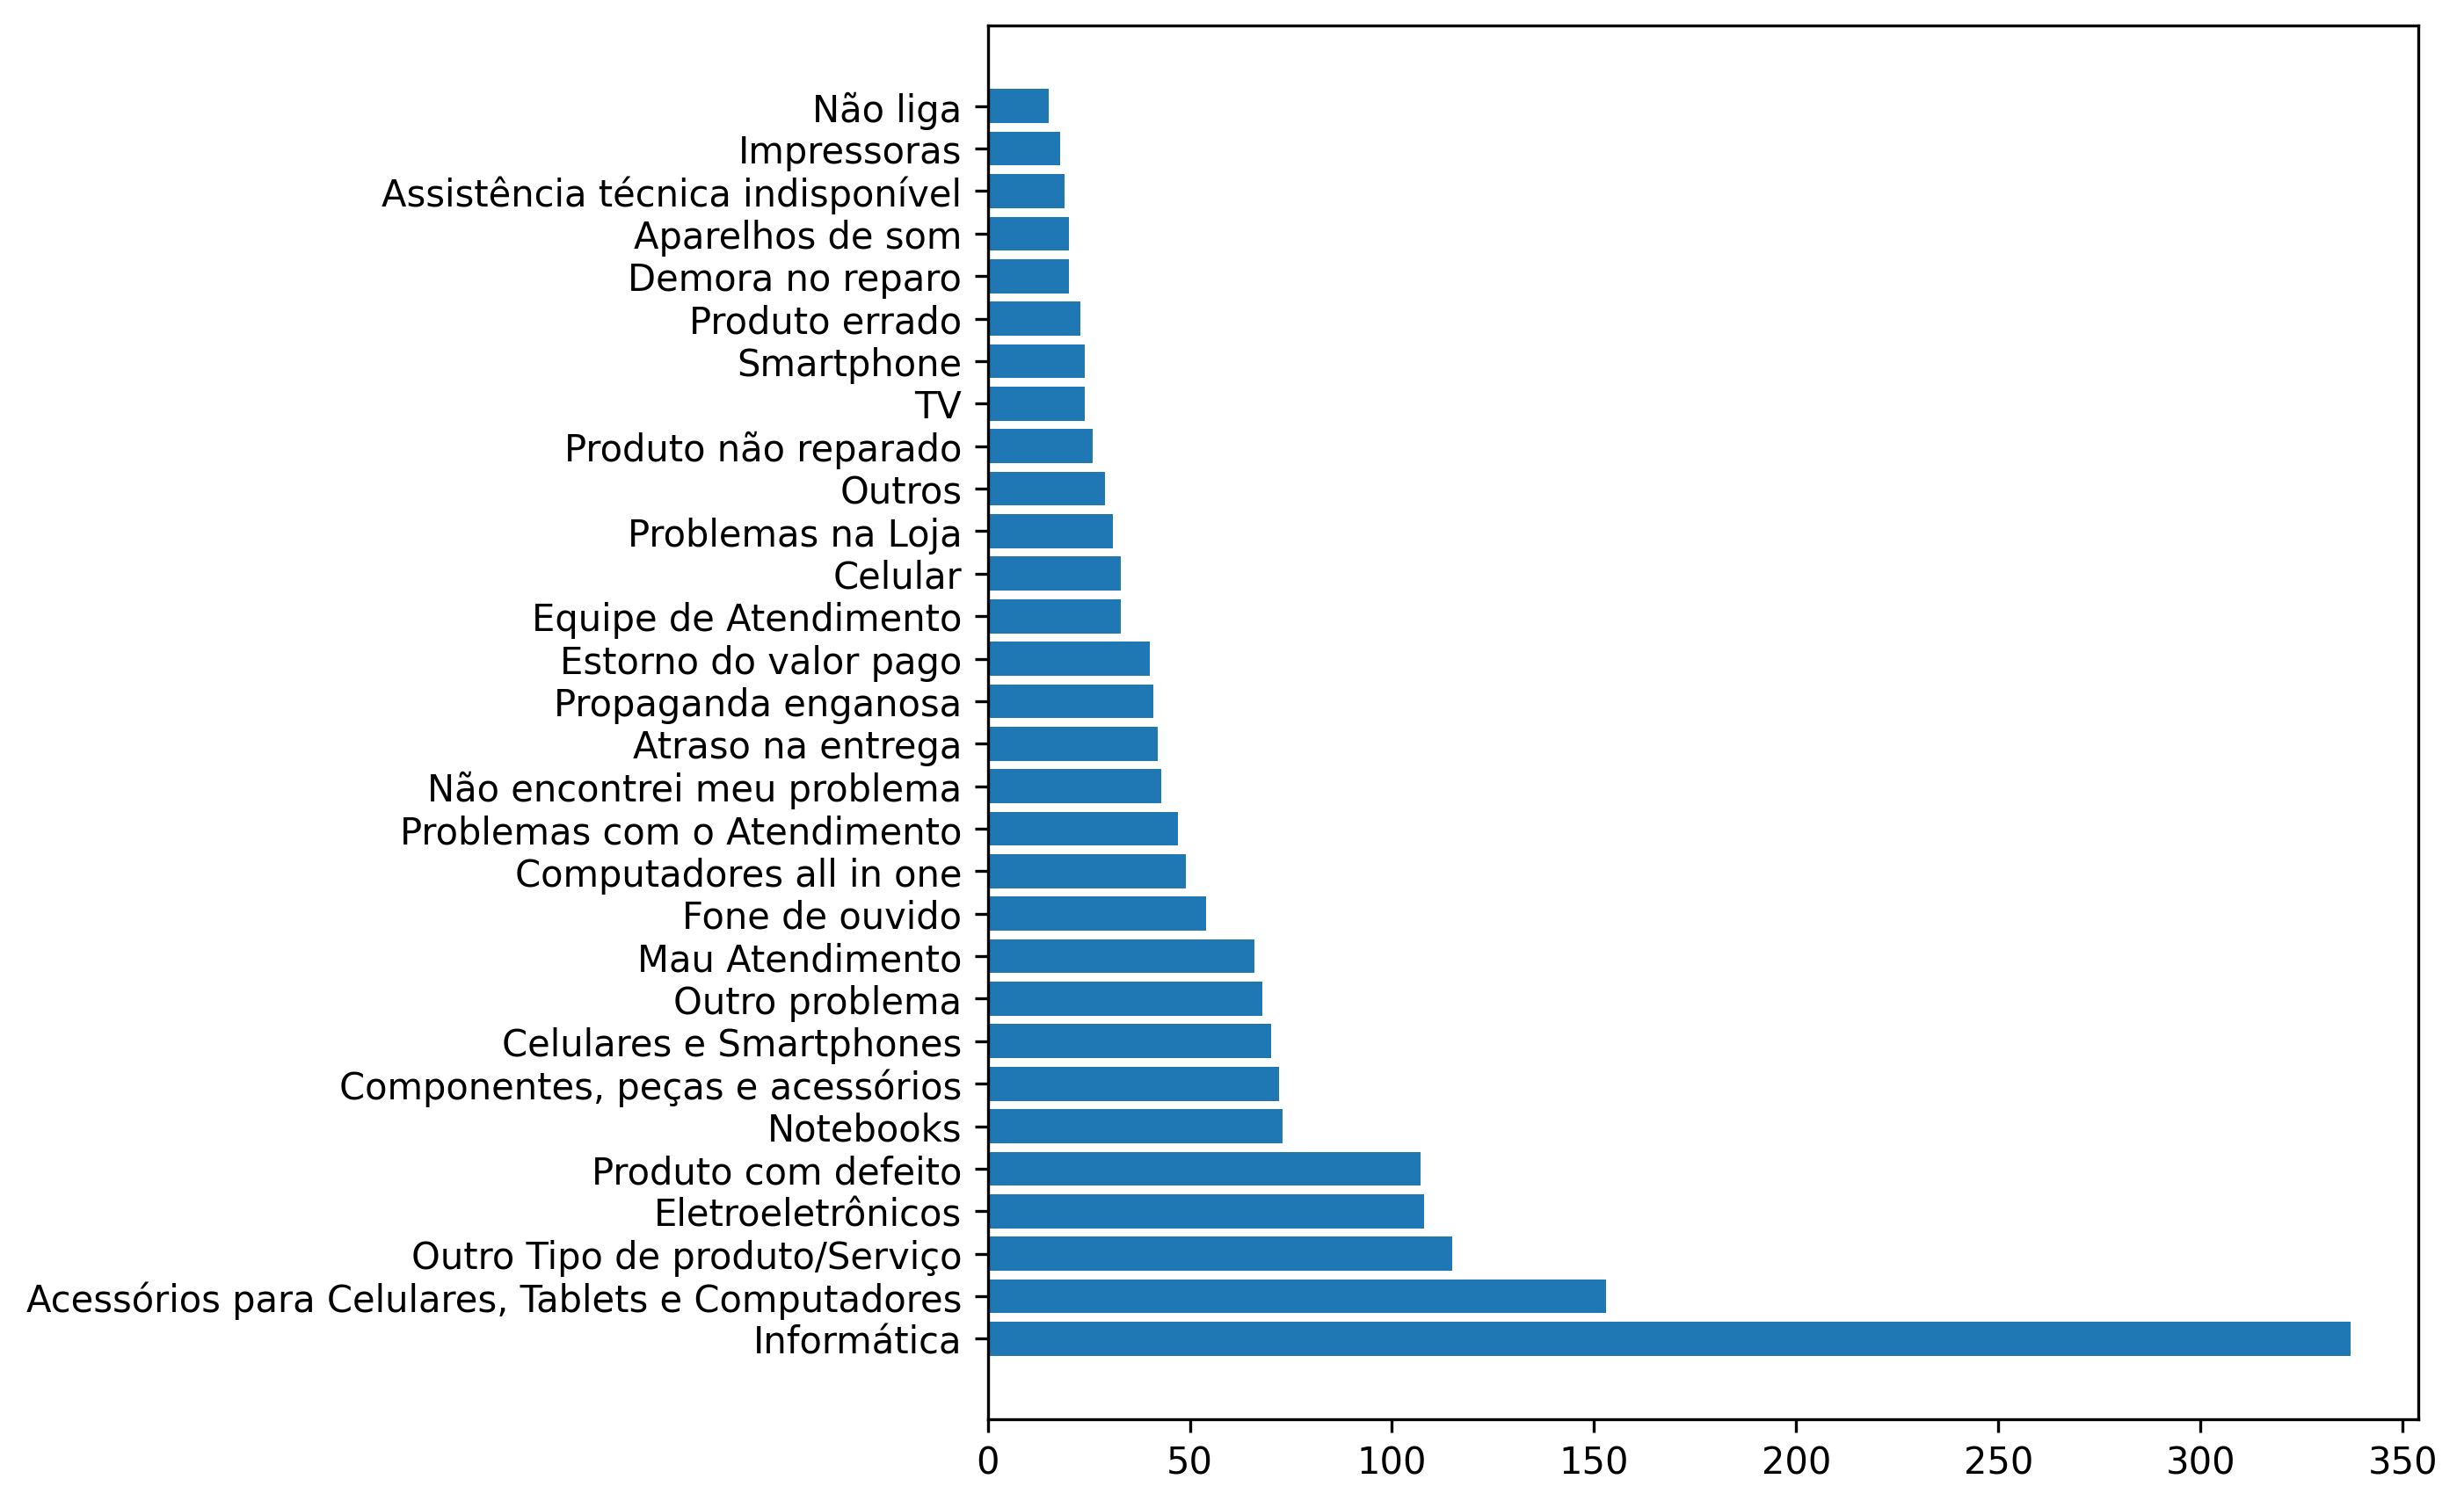

In [10]:
plt.figure(figsize=(7,7),dpi=300)
plt.barh(dc.CATEGORIA.value_counts().index[0:30],dc.CATEGORIA.value_counts().values[0:30])

# Redes

In [11]:
categorias=[]
for i in range(len(dfi)):
    lista=list(dfi.CATEGORIA.iloc[i].split('<->'))
    lista.remove(lixo)
    categorias.append(lista)

In [12]:
dfi['CATEGORIA_LISTA']=categorias

In [13]:
dfi['LEN_CAT']=dfi.CATEGORIA_LISTA.apply(len)

In [14]:
dfi.LEN_CAT.value_counts()

LEN_CAT
3    597
0    159
1    139
2     88
4     17
Name: count, dtype: int64

In [15]:
d1=dfi[dfi['LEN_CAT']>1].reset_index(drop=True)


In [16]:
d1.head()

,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS,CATEGORIA_LISTA,LEN_CAT
0,22581481,Solicitação de Cancelamento de Compra,Araxá - MG,2016-03-12,Não consigo fazer operação por telefone<->Cana...,Em réplica,"Prezados, efetuei uma compra no site www.ameri...",https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,3,12,72,10,5,1,2,"[Não consigo fazer operação por telefone, Cana...",3
1,22579385,Inutilizarão a tela do meu notebook,Fortaleza - CE,2016-03-12,Problemas na Loja<->Ibyte - Loja Física<->Prod...,Respondida,Decidi conserta meu notebook que parou de inic...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,3,12,72,10,5,1,2,"[Problemas na Loja, Produto danificado, Entrega]",3
2,21328791,Produto não faz o que vendedor informa!,Fortaleza - CE,2016-04-10,Ibyte - Loja Física<->Impressoras<->Produto er...,Em réplica,Venho através desde canal de reclamação expor ...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,4,10,101,14,6,2,1,"[Impressoras, Produto errado, Informática]",3
3,22608043,Ibyte não troca o produto,Fortaleza - CE,2016-05-12,Smartphone<->Celulares e Smartphones<->Blackfr...,Respondida,Comprei um celular na black Friday e com 4 dia...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,5,12,133,19,3,2,2,"[Smartphone, Celulares e Smartphones, Blackfri...",4
4,20766889,"IBYTE não quer restituir meu dinheiro, produto...",Fortaleza - CE,2016-06-09,Outros<->Ibyte - Loja Física<->Eletroeletrônic...,Resolvido,Dia 27/08/16 comprei um tablet GOLDENTEC 8GB 7...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,6,9,161,23,3,2,1,"[Outros, Eletroeletrônicos, Lentidão-travamento]",3


In [17]:
nn=len(dc.CATEGORIA.unique())
cateones=list(dc.CATEGORIA.unique())
matriz=np.zeros((nn,nn))

In [18]:
# matriz de co-ocorrencia
categorias=[]
for i in range(len(d1)):
    lista=list(d1.CATEGORIA.iloc[i].split('<->'))
    lista.remove(lixo)
    for i in range(len(lista)-1):
        for j in range(i+1,len(lista)):

            ii=cateones.index(lista[i])
            jj=cateones.index(lista[j])
            matriz[ii,jj]=matriz[ii,jj]+1
            matriz[jj,ii]=matriz[jj,ii]+1

In [19]:
dboll=pd.DataFrame(data=matriz,index=cateones,columns=cateones)

In [20]:
dboll

,Informática,Não consigo fazer operação por telefone,Canais de Atendimento,Problemas com o Atendimento,Problemas na Loja,Produto danificado,Entrega,Impressoras,Produto errado,Smartphone,...,Corrompido,Não reconhece USB,Controle remoto,Incompatível com o aparelho,Troca-Devolução de produto,Máquinas fotográficas-Filmadoras,Álbum de fotos,Não protegeu a tela,Películas para tela,Máquina fotográfica
Informática,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,17.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Não consigo fazer operação por telefone,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Canais de Atendimento,0.0,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Problemas com o Atendimento,0.0,3.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Problemas na Loja,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Máquinas fotográficas-Filmadoras,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Álbum de fotos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Não protegeu a tela,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Películas para tela,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [21]:
dboll.sum(axis=1)

Informática                                578.0
Não consigo fazer operação por telefone      6.0
Canais de Atendimento                       14.0
Problemas com o Atendimento                 82.0
Problemas na Loja                           38.0
                                           ...  
Máquinas fotográficas-Filmadoras             2.0
Álbum de fotos                               2.0
Não protegeu a tela                          2.0
Películas para tela                          2.0
Máquina fotográfica                          2.0
Length: 130, dtype: float64

In [22]:
dboll.sum(axis=0)

Informática                                578.0
Não consigo fazer operação por telefone      6.0
Canais de Atendimento                       14.0
Problemas com o Atendimento                 82.0
Problemas na Loja                           38.0
                                           ...  
Máquinas fotográficas-Filmadoras             2.0
Álbum de fotos                               2.0
Não protegeu a tela                          2.0
Películas para tela                          2.0
Máquina fotográfica                          2.0
Length: 130, dtype: float64

In [23]:
listap=dboll.sum(axis=0).sort_values(ascending=False).index[0:10].copy()

In [24]:
listap

Index(['Informática', 'Acessórios para Celulares, Tablets e Computadores',
       'Produto com defeito', 'Eletroeletrônicos',
       'Outro Tipo de produto/Serviço', 'Notebooks',
       'Componentes, peças e acessórios', 'Mau Atendimento',
       'Celulares e Smartphones', 'Outro problema'],
      dtype='object')

In [25]:
source=[]
target=[]
weight=[]

for b1 in cateones:
    for b2 in cateones:
        #cuidado com a ordem, pandas é diferente
        if dboll.loc[b1][b2]!=0:
            source.append(b1)
            target.append(b2)
            weight.append(dboll.loc[b1][b2])

dd=pd.DataFrame({'ORIGEM':source,'DESTINO':target,'W':weight})

In [26]:
dd.W.min()

1.0

In [27]:
G0 = nx.from_pandas_edgelist(dd,'ORIGEM','DESTINO','W')

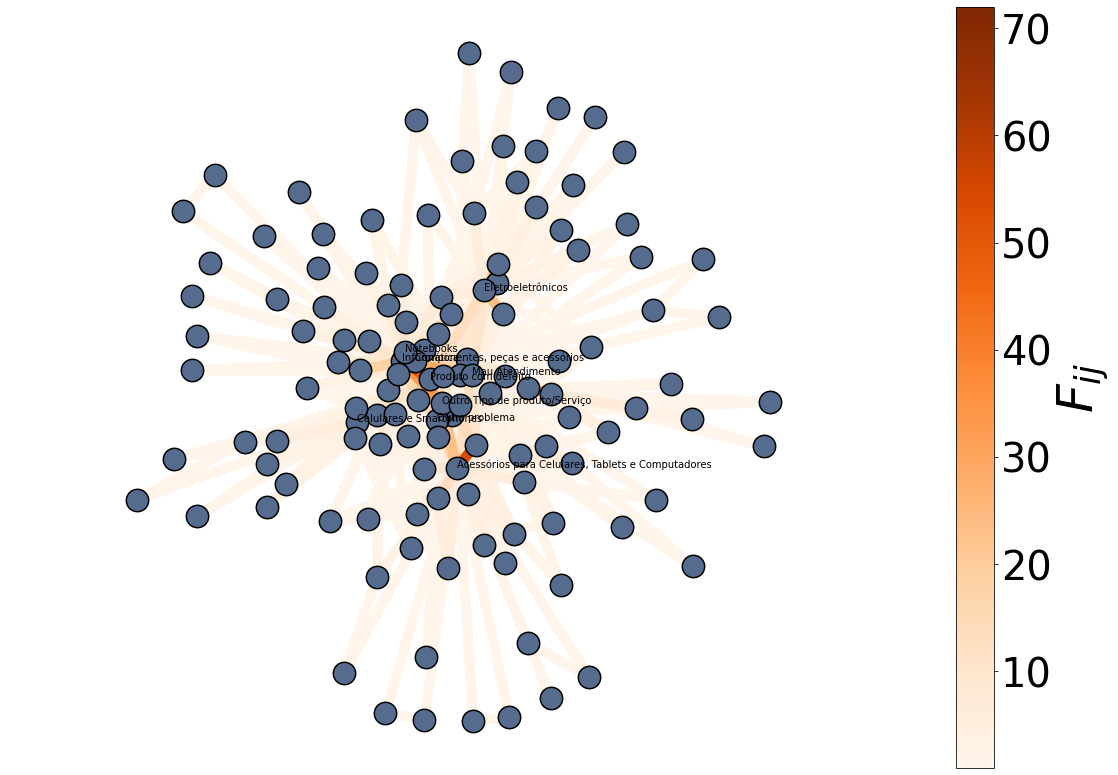

In [28]:
plt.figure(figsize=(20,14))
#plt.figure(figsize=(20,16))
plt.xlabel(' ')
plt.ylabel(' ')
plt.axis('off')
plt.axis('equal')

dgrapg=dd[(dd['ORIGEM']!=dd['DESTINO'])].sort_values('W').reset_index(drop=True).copy()
#dgrapg=dd.sort_values('W').reset_index(drop=True).copy()
z=dgrapg.reset_index(drop=True).W.values

normal = plt.Normalize(min(z), max(z))
pos = nx.spring_layout(G0,iterations=20000,weight='W',seed=42)
cmap = plt.cm.Oranges(normal(z))
for i in range(len(dgrapg)):
    G = nx.from_pandas_edgelist(dgrapg[i:i+1],'ORIGEM','DESTINO','W')

    caux=plt.cm.Oranges(normal(dgrapg[i:i+1].W.values[0]))
    waux=normal(dgrapg[i:i+1].W.values[0])*20
    waux=10.0
    aux=normal(dgrapg[i:i+1].W.values[0]+1)*10
    nx.draw_networkx_edges(G, pos, edge_color= caux,alpha=1.0,edge_cmap=plt.cm.Oranges,width=waux)

cmap='Oranges'
sm = plt.cm.ScalarMappable(cmap=cmap, norm=normal)
cb = plt.colorbar(sm)
cb.set_label(label=r'$ F_{ij}$',size=50)


for t in cb.ax.get_yticklabels():
    t.set_fontsize(40)

i=0
for d in pos.keys():
    plt.scatter(pos[d][0],pos[d][1],s=500,zorder=2,edgecolor='black',lw=1.5,c='#556C8E')
    i=i+1
    if d in listap:
        plt.annotate(d,xy=(pos[d][0],pos[d][1]),fontsize=10)

In [29]:
[
    len(c)
    for c in sorted(nx.connected_components(G0), key=len, reverse=True)
]

[128]

In [30]:
nx.maximum_spanning_tree(G0, weight='W', algorithm='kruskal')

In [31]:
source=[]
target=[]
weight=[]
for a,b in nx.maximum_spanning_tree(G0, weight='W', algorithm='kruskal').edges:
    source.append(a)
    target.append(b)
    weight.append(dd[(dd['ORIGEM']==a)&(dd['DESTINO']==b)].W.values[0])

In [32]:
d0=pd.DataFrame({'ORIGEM':source,'DESTINO':target,'W':weight})

In [33]:
G00 = nx.from_pandas_edgelist(d0,'ORIGEM','DESTINO','W')

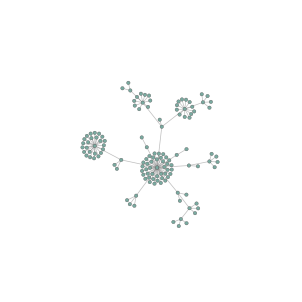

In [34]:
from netwulf import visualize
results=visualize(G00)

In [35]:
pj=results[0]['nodes']

In [36]:
posx={}
for i in range(len(pj)):
    posx[pj[i]['id']]=np.array([pj[i]['x'],pj[i]['y']])

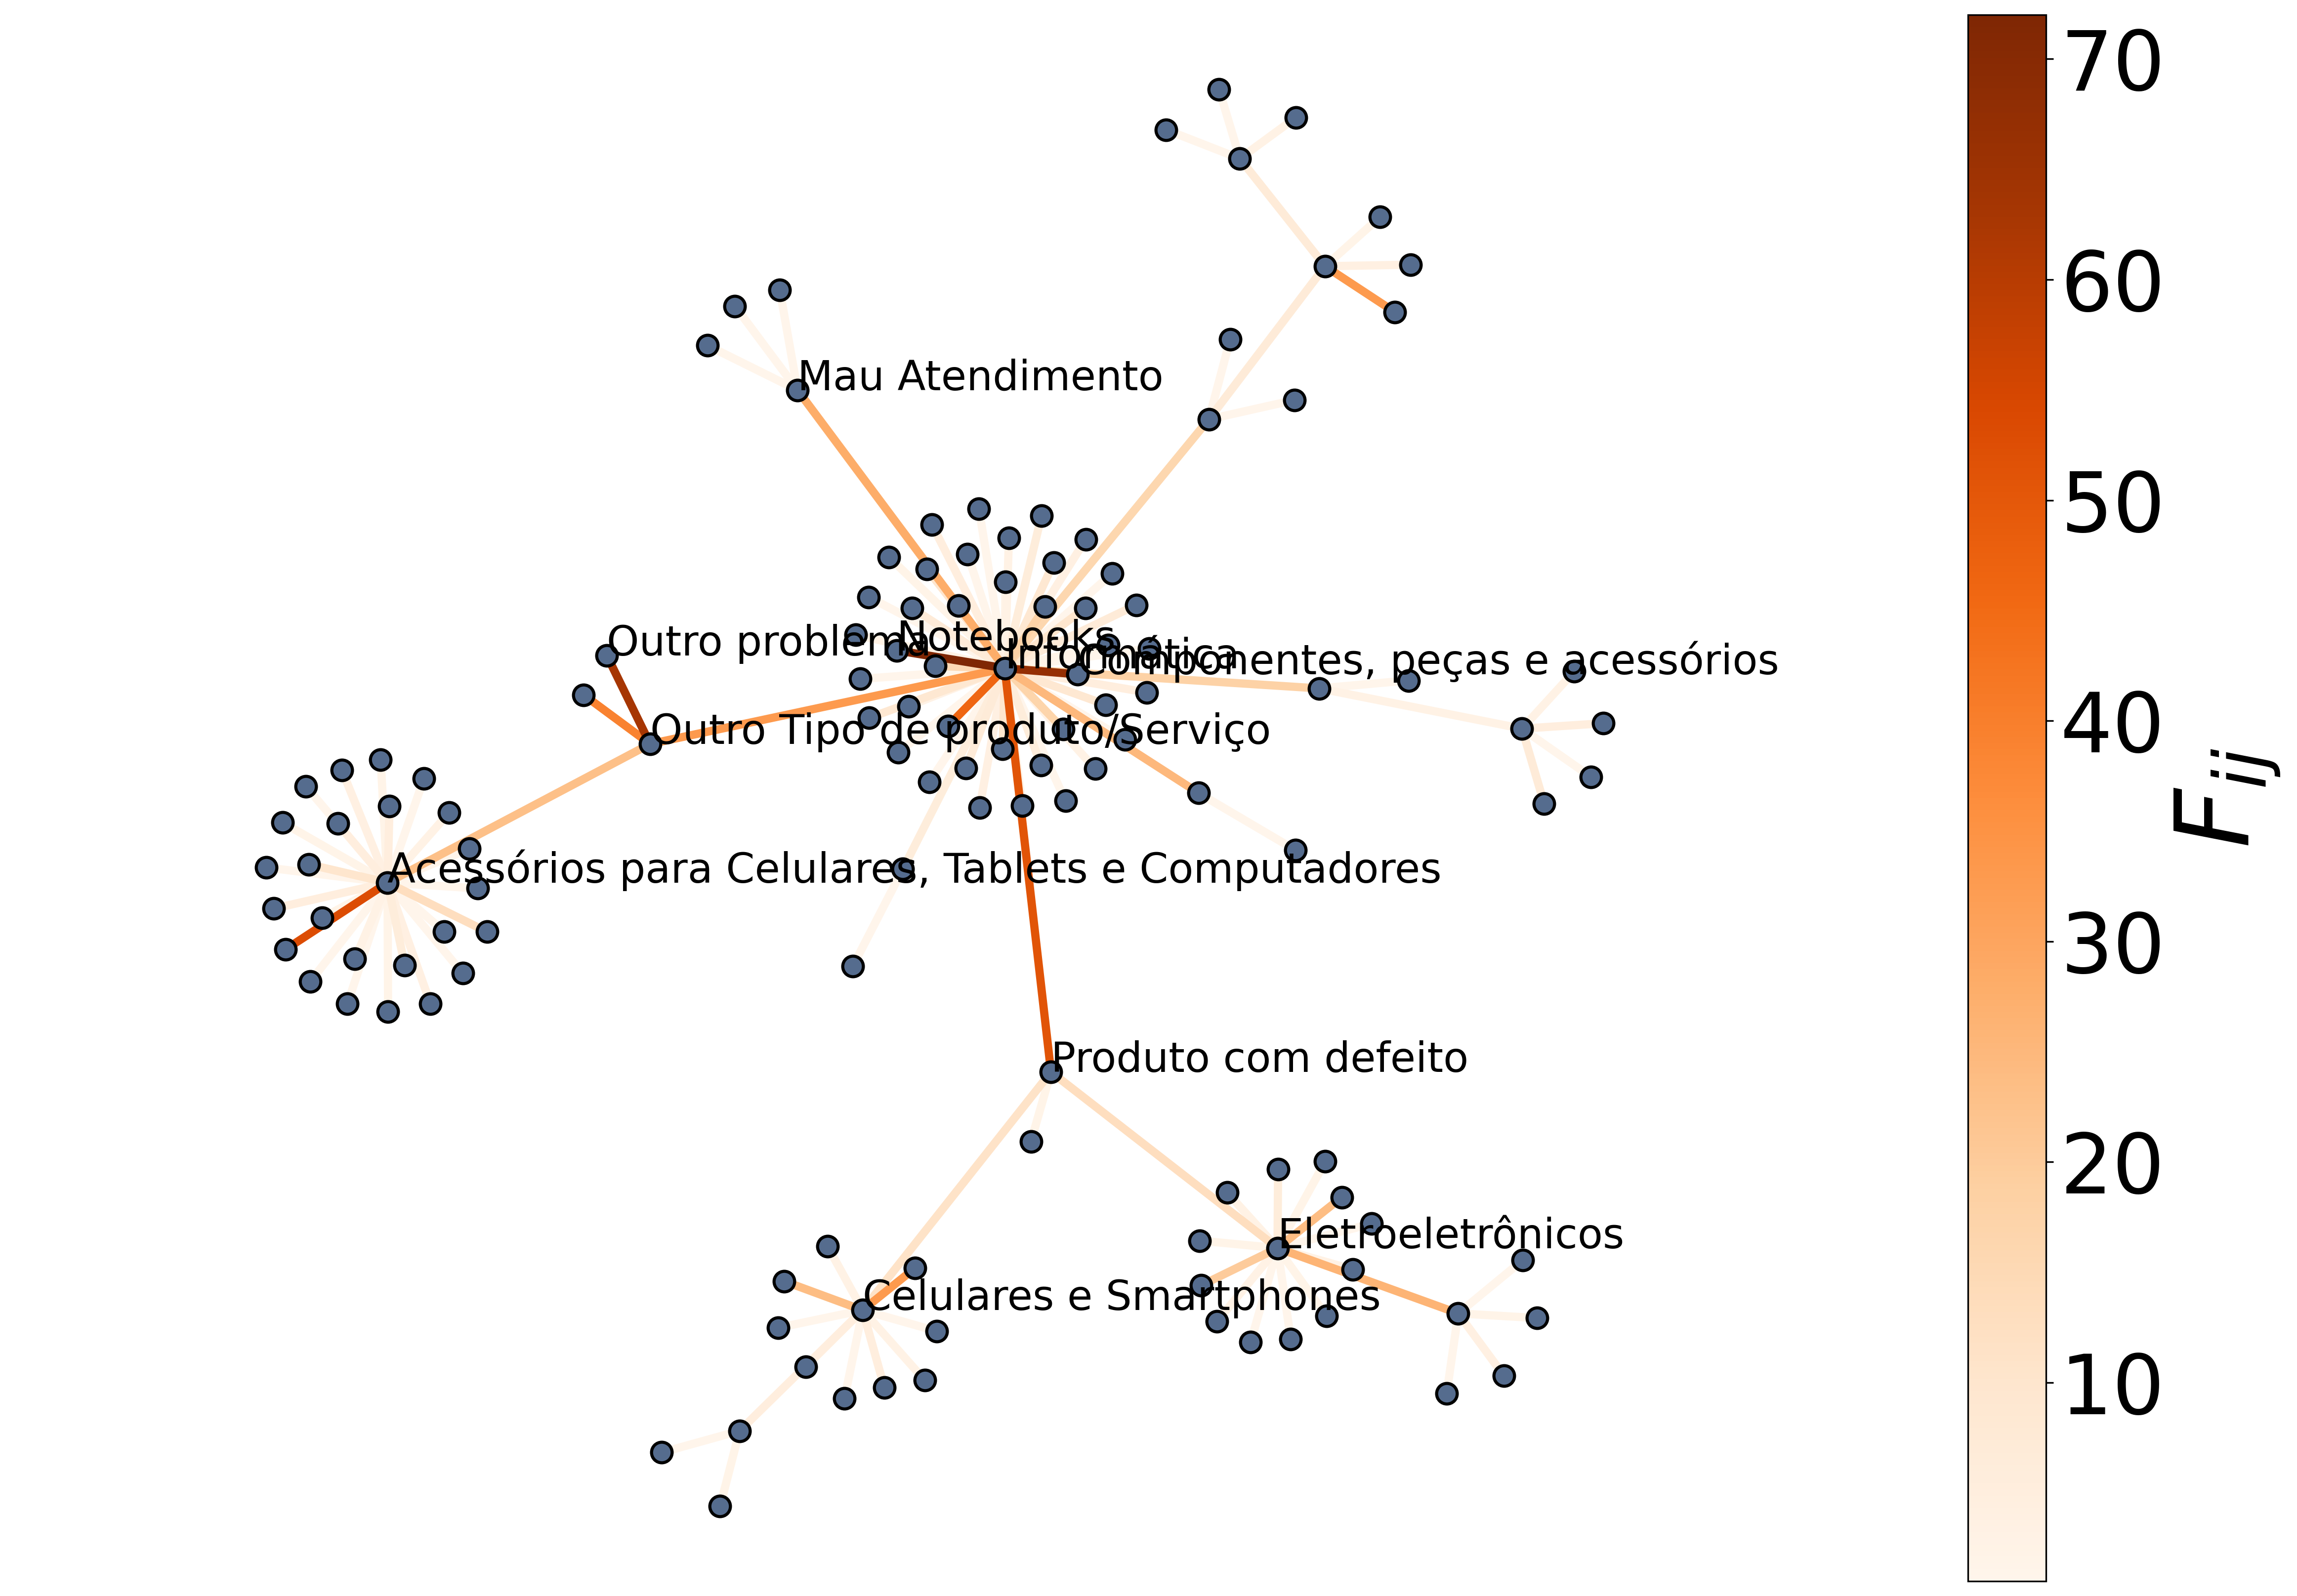

In [37]:
plt.figure(figsize=(20,14),dpi=300)
#plt.figure(figsize=(20,16))
plt.xlabel(' ')
plt.ylabel(' ')
plt.axis('off')
plt.axis('equal')

dgrapg=d0.sort_values('W').reset_index(drop=True).copy()

z=dgrapg.reset_index(drop=True).W.values

normal = plt.Normalize(min(z), max(z))

cmap = plt.cm.Oranges(normal(z))
for i in range(len(dgrapg)):
    G = nx.from_pandas_edgelist(dgrapg[i:i+1],'ORIGEM','DESTINO','W')

    caux=plt.cm.Oranges(normal(dgrapg[i:i+1].W.values[0]))
    waux=normal(dgrapg[i:i+1].W.values[0])*10
    waux=4.0
    #waux=1.0
    aux=normal(dgrapg[i:i+1].W.values[0])*10
    aux=15.0
    nx.draw_networkx_edges(G, posx, edge_color= caux,alpha=1.0,edge_cmap=plt.cm.Oranges,width=waux)

cmap='Oranges'
sm = plt.cm.ScalarMappable(cmap=cmap, norm=normal)
cb = plt.colorbar(sm)
cb.set_label(label=r'$ F_{ij}$',size=50)

for t in cb.ax.get_yticklabels():
    t.set_fontsize(40)
    

i=0
for d in posx.keys():
    plt.scatter(posx[d][0],posx[d][1],s=100,zorder=2,edgecolor='black',lw=1.5,c='#556C8E')
    if d in listap:
        plt.annotate(d,xy=(posx[d][0],posx[d][1]),fontsize=20)
    

In [38]:
dfi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               1000 non-null   int64 
 1   TEMA             1000 non-null   object
 2   LOCAL            1000 non-null   object
 3   TEMPO            1000 non-null   object
 4   CATEGORIA        1000 non-null   object
 5   STATUS           1000 non-null   object
 6   DESCRICAO        1000 non-null   object
 7   URL              1000 non-null   object
 8   ANO              1000 non-null   int64 
 9   MES              1000 non-null   int64 
 10  DIA              1000 non-null   int64 
 11  DIA_DO_ANO       1000 non-null   int64 
 12  SEMANA_DO_ANO    1000 non-null   int64 
 13  DIA_DA_SEMANA    1000 non-null   int64 
 14  TRIMETRES        1000 non-null   int64 
 15  CASOS            1000 non-null   int64 
 16  CATEGORIA_LISTA  1000 non-null   object
 17  LEN_CAT          1000 non-null   i

In [39]:
dfi.drop('CATEGORIA_LISTA',axis=1).nunique()

ID               1000
TEMA              960
LOCAL             121
TEMPO             766
CATEGORIA         331
STATUS              5
DESCRICAO         998
URL              1000
ANO                 7
MES                12
DIA                31
DIA_DO_ANO        338
SEMANA_DO_ANO      53
DIA_DA_SEMANA       7
TRIMETRES           4
CASOS               5
LEN_CAT             5
dtype: int64

In [40]:
texto='Fiz uma compra de uma caixa jbl go no dia 28/09/2019, na loja ibyte no shopping benfica em fortaleza. chegando em casa a caixa estava com defeito. voltei no dia seguinte menos de 24h depois, e o vendedor disse q n poderia fazer minha troca pois o gerente n estava la pra autorizar, mais q eu fosse no dia segunite pra q fosse resolvido. chegando la no dia seguinte o gerente disse q nao poderia trocar me produto e que eu mandasse para a assistencia. mais por lei temos direito de troca na loja em ate 72h. sem falar q o vendedor nem testou o produto na hora da venda. muita falta de respeito e pessimo atendimento dos funcionarios dessa loja q n movem um dedo pra resolver seu problema.'

In [41]:
dfi[dfi.DESCRICAO==texto]

,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS,CATEGORIA_LISTA,LEN_CAT
435,95677097,Loja nao trocou meu aparelho com problema em m...,Fortaleza - CE,2019-01-10,Bluetooth<->Aparelhos de som<->Ibyte - Loja Fí...,Respondida,Fiz uma compra de uma caixa jbl go no dia 28/0...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2019,1,10,10,2,3,1,1,"[Bluetooth, Aparelhos de som, Eletroeletrônicos]",3
529,95639461,Ibyte nao troca meu produto.,Fortaleza - CE,2019-09-30,Bluetooth<->Aparelhos de som<->Ibyte - Loja Fí...,Resolvido,Fiz uma compra de uma caixa jbl go no dia 28/0...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2019,9,30,273,40,0,3,1,"[Bluetooth, Aparelhos de som, Eletroeletrônicos]",3


In [42]:
dfi.DESCRICAO.value_counts()

DESCRICAO
Venho ao reclame aqui falar da fragilidade dos produtos da Goldentec, que é vendido pela Ibyte. Já tive problema com um carregador da mesma marca, mas este foi trocado e não deu defeito novamente. A pouco mais de 1 ano comprei um mouse na loja Ibyte da Parangaba e ele veio a apresentar defeito. Voltei na loja e me falaram que não podia ser feito nada, pq a garantia já havia acabado. Eu questionei se poderia ser consertado, mesmo eu arcando com o conserto, e essa possibilidade me foi negada. Concluo que o tempo de uso da marca é baixíssimo. Estou chateada.                                                                                                                                                                                                                                                                                                                                                                                                                                             

<BarContainer object of 30 artists>

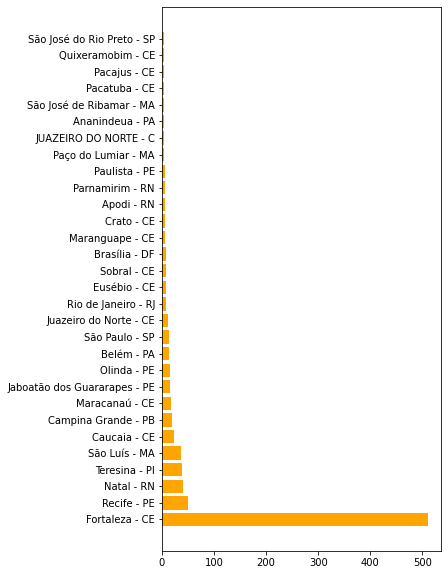

In [43]:
aux=dfi.LOCAL.value_counts().copy()
plt.figure(figsize=(5,10))
plt.barh(aux.index[0:30],aux.values[0:30],color='orange')



<BarContainer object of 5 artists>

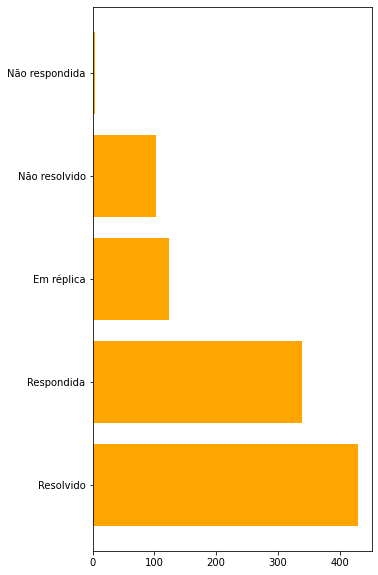

In [44]:
aux=dfi.STATUS.value_counts().copy()
plt.figure(figsize=(5,10))
plt.barh(aux.index[0:30],aux.values[0:30],color='orange')

In [45]:
dfi.ANO.value_counts().sort_values()

ANO
2016     69
2022    112
2019    123
2020    158
2018    173
2021    175
2017    190
Name: count, dtype: int64

<BarContainer object of 7 artists>

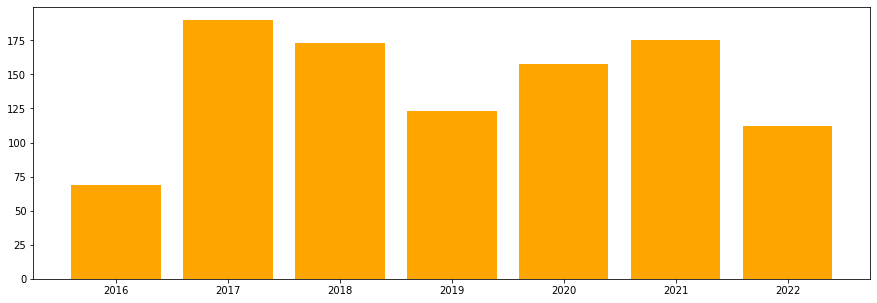

In [46]:
aux=dfi.ANO.value_counts().sort_index().copy()
plt.figure(figsize=(15,5))
plt.bar(aux.index,aux.values,color='orange')

In [47]:
df=dfi.copy()

In [48]:
df['TEMPO']=pd.to_datetime(df['TEMPO'])
df['ANO'] = pd.DatetimeIndex(df['TEMPO']).year
df['MES'] = pd.DatetimeIndex(df['TEMPO']).month
df['DIA'] = pd.DatetimeIndex(df['TEMPO']).day
df['DIA_DO_ANO'] = pd.DatetimeIndex(df['TEMPO']).dayofyear
df['SEMANA_DO_ANO'] = pd.DatetimeIndex(df['TEMPO']).week
df['DIA_DA_SEMANA']= pd.DatetimeIndex(df['TEMPO']).weekday
df['TRIMETRES'] = pd.DatetimeIndex(df['TEMPO']).quarter

AttributeError: 'DatetimeIndex' object has no attribute 'week'

In [ ]:
df[['ID','TEMPO']].groupby('TEMPO').count()

In [ ]:
d1=df[['ID','TEMPO']].groupby('TEMPO').nunique().drop('TEMPO',axis=1).reset_index().rename(columns={'ID':'CASOS'}).copy()

In [ ]:
d1.set_index('TEMPO').rolling(30).mean().plot()

In [ ]:
d1.set_index('TEMPO').cumsum().plot()

In [ ]:
df